Notes:
- Electricy prices seem unrealistic, should possibly be per MWh instead of per KWh

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
hourly_data = pd.read_csv('hourly.csv')
daily_data = pd.read_csv('daily.csv')
weekly_data = pd.read_csv('weekly.csv')

print((hourly_data["Production_Actual_MWh"] == 0).sum())

3


In [ ]:
# Storage Capacity and Initial Levels
HYDROGEN_STORAGE_CAPACITY_KG = 86000  # Maximum hydrogen storage capacity in kg (86 tonnes)
HYDROGEN_INITIAL_LEVEL_KG = 10000     # Initial hydrogen level on 1st Jan 2022 in kg (10 tonnes)

# Conversion Parameters
HYDROGEN_CONVERSION_EFFICIENCY = 0.74     # Efficiency (74% retained)

# Production Rate
CONVERSION_RATE_KWH_PER_KG = 40        # KG required to produce 1 KWh

# Operational Timing
ELECTROLYSER_TURNAROUND_TIME_HOURS = 0.5  # Hours of downtime when switching modes

# Market Parameters
ELECTRICITY_MARKET_OVERHEAD = 0.10   # Transaction cost (10%)

In [ ]:
"""
Preprocess data
"""
# Hourly
hourly_data = hourly_data[(hourly_data != 0).all(axis=1)]
actual_production = hourly_data["Production_Actual_MWh"]
forecasted_production_1 = hourly_data["Production_Forecast_1hour_MWh"]
forecasted_production_6 = hourly_data["Production_Forecast_6hour_MWh"]
forecasted_production_24 = hourly_data["Production_Forecast_24hour_MWh"]
wind_speed = hourly_data["Wind_Speed_Actual_Knots"]
electricity_production = hourly_data["Production_Actual_MWh"]
current_prices = hourly_data["Electricity_Prices_Spot_Dollar"]
day_ahead_prices_data = hourly_data["Electricity_Prices_Day_Ahead_Dollar"]
hourly_timestamps = pd.to_datetime(hourly_data["DateHour"], dayfirst=True)

# Daily
daily_data = daily_data[(daily_data != 0).all(axis=1)]
actual_hydrogen_demand = daily_data["Hydrogen_Demand_Actual_KG"]
actual_electricity_demand = actual_hydrogen_demand / 40
forecasted_hydrogen_demand = daily_data["Hydrogen_Demand_Forecast_KG"]
daily_timestamps = pd.to_datetime(daily_data["Date"], dayfirst=True)

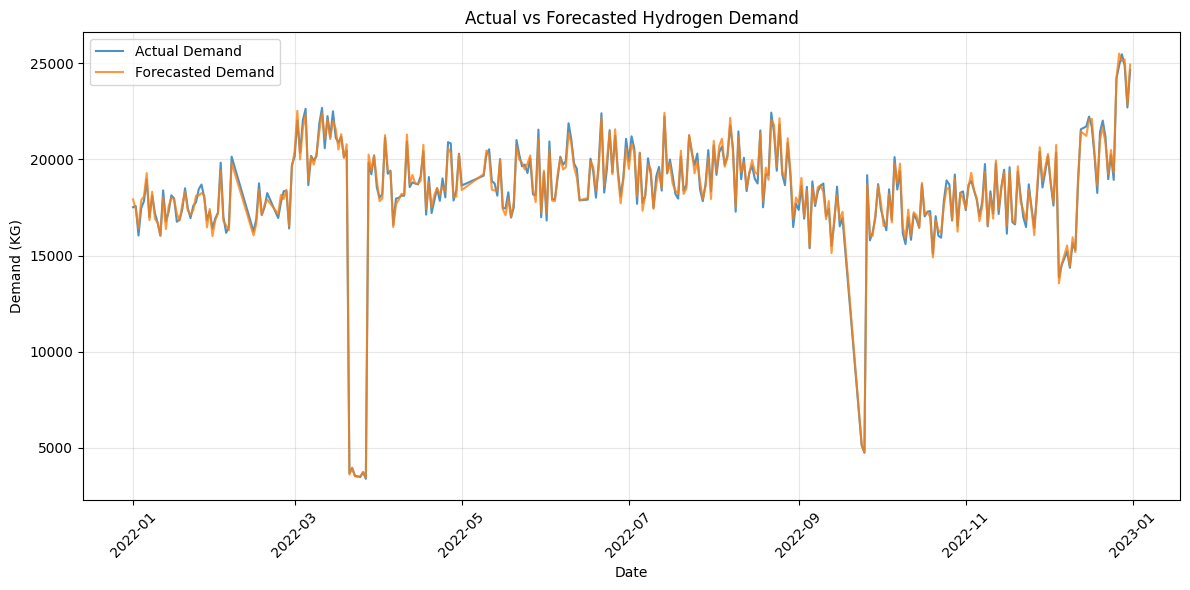

Mean demand: 18386.74480712166 kg
Max percentage error: 2.565564424173318%
MAPE: 1.30%
RMSE: 275.72 KG
MAE: 239.46 KG
R²: 0.9917


In [ ]:
"""
Check hydrogen forecast accuracy
"""
# Plot actual vs forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_timestamps, actual_hydrogen_demand, label='Actual Demand', alpha=0.8)
plt.plot(daily_timestamps, forecasted_hydrogen_demand, label='Forecasted Demand', alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Demand (KG)')
plt.title('Actual vs Forecasted Hydrogen Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print metrics
mape = np.mean(np.abs((actual_hydrogen_demand - forecasted_hydrogen_demand) / actual_hydrogen_demand)) * 100
rmse = np.sqrt(np.mean((actual_hydrogen_demand - forecasted_hydrogen_demand)**2))
mae = np.mean(np.abs(actual_hydrogen_demand - forecasted_hydrogen_demand))
r2 = 1 - np.sum((actual_hydrogen_demand - forecasted_hydrogen_demand)**2) / np.sum((actual_hydrogen_demand - np.mean(actual_hydrogen_demand))**2)
mean_hydrogen_demand = np.mean(actual_hydrogen_demand)

print(f"Mean demand: {mean_hydrogen_demand} kg")
print(f"Max percentage error: {max(abs(actual_hydrogen_demand - forecasted_hydrogen_demand) / actual_hydrogen_demand) * 100}%")
print(f'MAPE: {mape:.2f}%')
print(f'RMSE: {rmse:.2f} KG')
print(f'MAE: {mae:.2f} KG')
print(f'R²: {r2:.4f}')

Conclusion: Hydrogen demand forecast from training data seems very reliable, not sure if test data will be the same

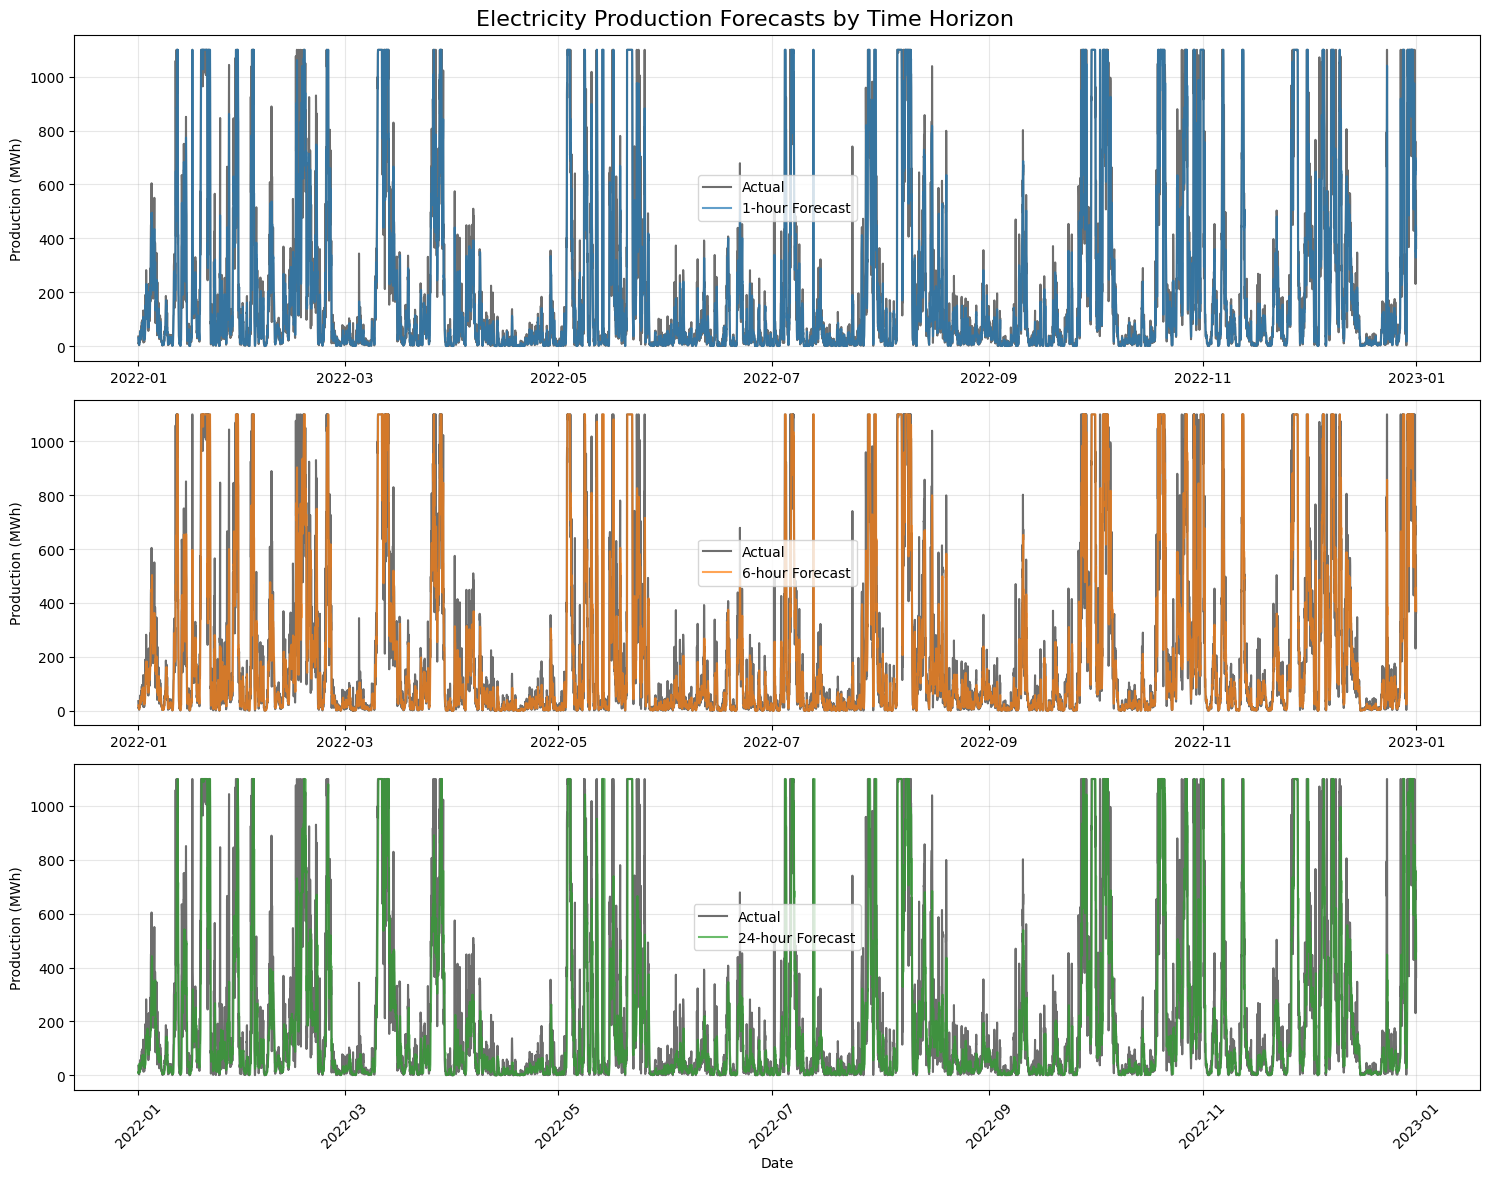


FORECAST PERFORMANCE SUMMARY
Metric          1-hour       6-hour       24-hour     
------------------------------------------------------------
MAE (MWh)       32.89        46.56        67.90       
RMSE (MWh)      74.44        101.99       150.13      
MAPE (%)        710.88       2327.24      2480.40     
R²              0.9462       0.8989       0.7810      
Bias (MWh)      -12.73       -18.73       -27.95      


In [ ]:
"""
Check electricity production forecasts
"""
def calculate_metrics(actual, forecast):
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast)**2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    r2 = 1 - np.sum((actual - forecast)**2) / np.sum((actual - np.mean(actual))**2)
    bias = np.mean(forecast - actual)
    return mae, rmse, mape, r2, bias

# Create subplots for each forecast horizon
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Electricity Production Forecasts by Time Horizon', fontsize=16)

forecasts = [
    (forecasted_production_1, '1-hour Forecast', '#1f77b4'),
    (forecasted_production_6, '6-hour Forecast', '#ff7f0e'),
    (forecasted_production_24, '24-hour Forecast', '#2ca02c')
]
for i, (forecast, label, color) in enumerate(forecasts):
    axes[i].plot(hourly_timestamps, actual_production, label='Actual', color='#4A4A4A', alpha=0.8)
    axes[i].plot(hourly_timestamps, forecast, label=label, color=color, alpha=0.7)
    axes[i].set_ylabel('Production (MWh)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary comparison table
print("\n" + "="*60)
print("FORECAST PERFORMANCE SUMMARY")
print("="*60)

metrics_1h = calculate_metrics(actual_production, forecasted_production_1)
metrics_6h = calculate_metrics(actual_production, forecasted_production_6)
metrics_24h = calculate_metrics(actual_production, forecasted_production_24)

print(f"{'Metric':<15} {'1-hour':<12} {'6-hour':<12} {'24-hour':<12}")
print("-" * 60)
print(f"{'MAE (MWh)':<15} {metrics_1h[0]:<12.2f} {metrics_6h[0]:<12.2f} {metrics_24h[0]:<12.2f}")
print(f"{'RMSE (MWh)':<15} {metrics_1h[1]:<12.2f} {metrics_6h[1]:<12.2f} {metrics_24h[1]:<12.2f}")
print(f"{'MAPE (%)':<15} {metrics_1h[2]:<12.2f} {metrics_6h[2]:<12.2f} {metrics_24h[2]:<12.2f}")
print(f"{'R²':<15} {metrics_1h[3]:<12.4f} {metrics_6h[3]:<12.4f} {metrics_24h[3]:<12.4f}")
print(f"{'Bias (MWh)':<15} {metrics_1h[4]:<12.2f} {metrics_6h[4]:<12.2f} {metrics_24h[4]:<12.2f}")

Conclusion: Electrictiy production forecasts seem unreliable, we could possibly train a new model get better results

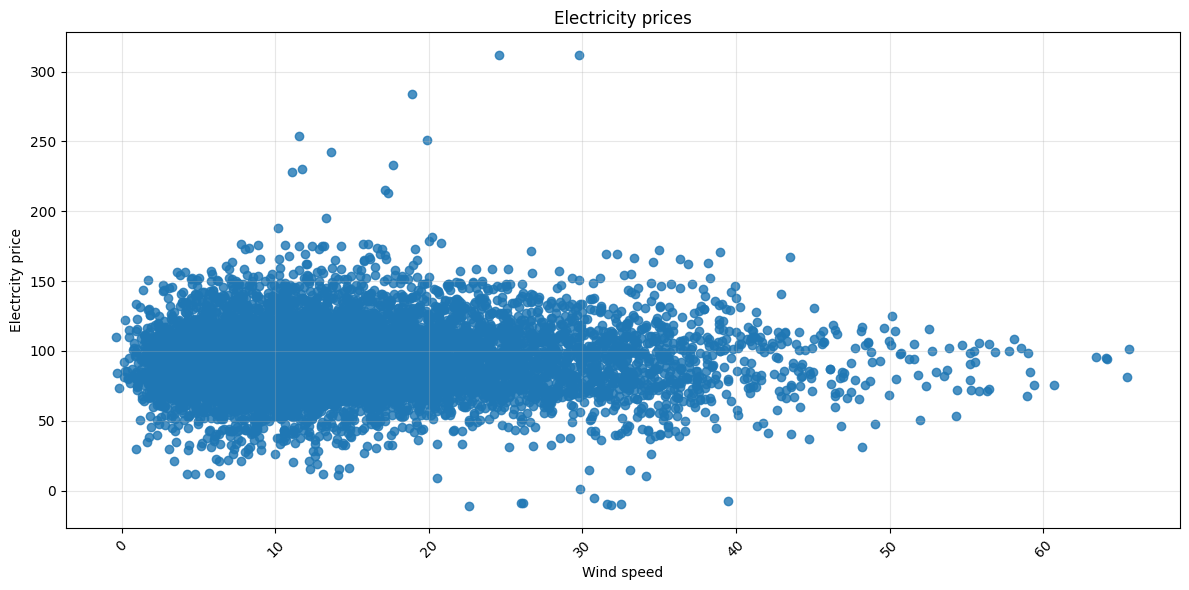

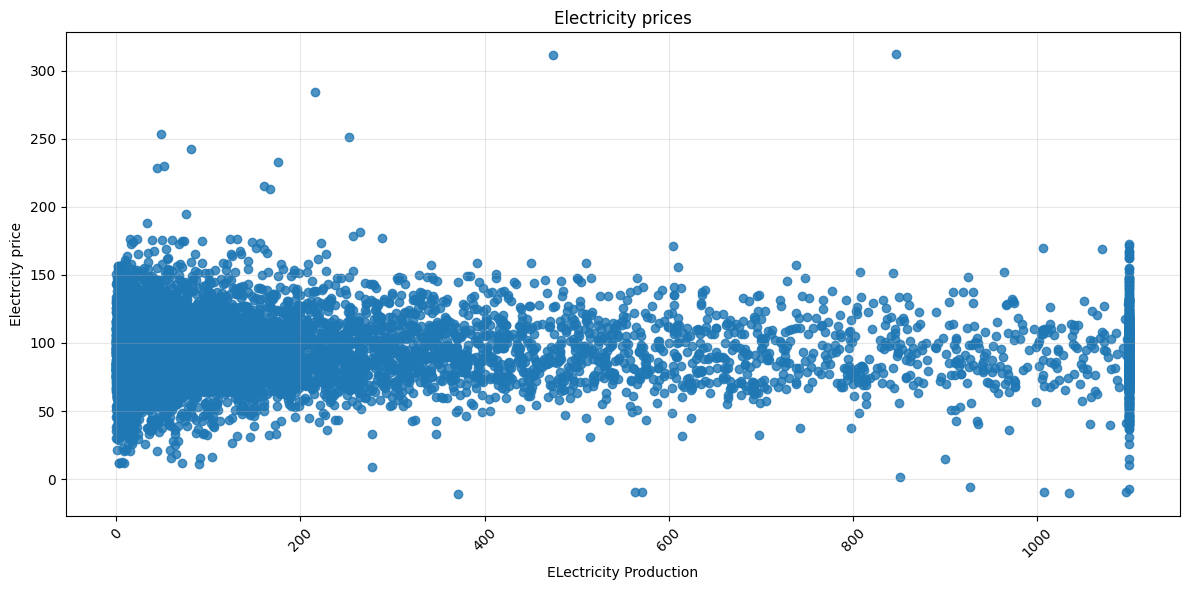

In [ ]:
"""
Find electricty price correlations
"""
# Plot price against wind speed
plt.figure(figsize=(12, 6))
plt.scatter(wind_speed, current_prices, alpha=0.8,)
plt.xlabel('Wind speed')
plt.ylabel('Electrcity price')
plt.title('Electricity prices')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()


# Plot price against production
plt.figure(figsize=(12, 6))
plt.scatter(electricity_production, current_prices, alpha=0.8,)
plt.xlabel('ELectricity Production')
plt.ylabel('Electrcity price')
plt.title('Electricity prices')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Conclusion: Electricity production capped at 1100 MWh. No interesting correlation between produciton and prices from this data

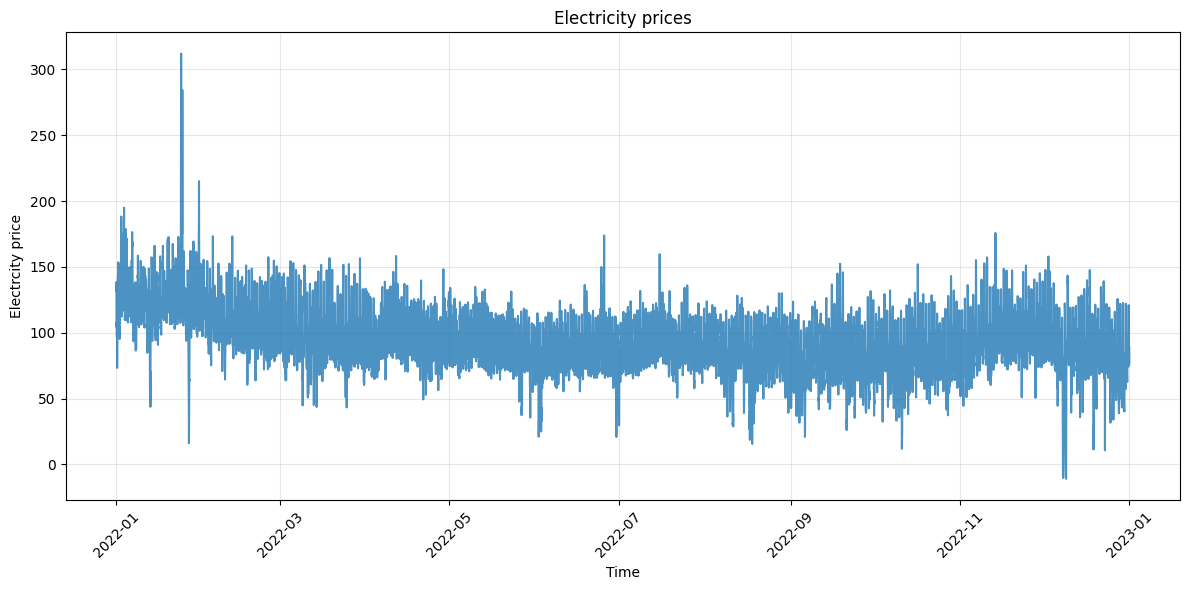

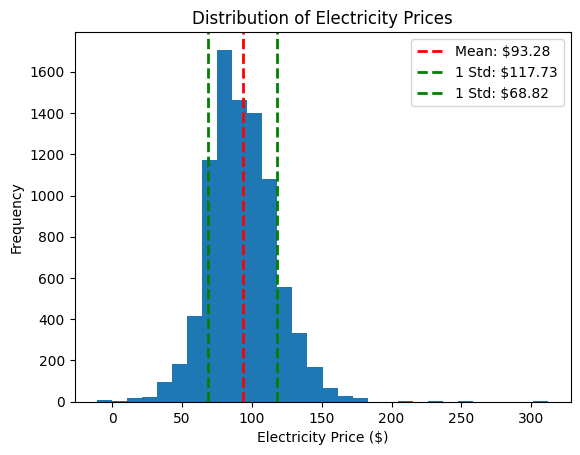

Range(0-30): 43
Range(30-60): 480
Range(60-90): 3669
Range(90-120): 3498
Range(120-150): 931
Range(150-180): 122
Range(180-210): 3
Range(210-240): 5
Range(240-270): 3
Range(270-300): 1
Range(300-330): 2


In [ ]:
"""
Explore the price data
"""
mean_price = current_prices.mean()
std_price = current_prices.std()
min_price = current_prices.min()
max_price = current_prices.max()

# Plot price time series
plt.figure(figsize=(12, 6))
plt.plot(hourly_timestamps, current_prices, alpha=0.8,)
plt.xlabel('Time')
plt.ylabel('Electrcity price')
plt.title('Electricity prices')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot histogram
plt.hist(hourly_data["Electricity_Prices_Spot_Dollar"], bins=30)
plt.xlabel("Electricity Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Prices")
plt.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:.2f}')
plt.axvline(mean_price + std_price, color='green', linestyle='--', linewidth=2, label=f'1 Std: ${mean_price + std_price:.2f}')
plt.axvline(mean_price - std_price, color='green', linestyle='--', linewidth=2, label=f'1 Std: ${mean_price - std_price:.2f}')
plt.legend()
plt.show()

prev_count = 0
ranges = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
for i in range(1, len(ranges)):
    cur_count = (hourly_data["Electricity_Prices_Spot_Dollar"] <= ranges[i]).sum()
    print(f"Range({ranges[i-1]}-{ranges[i]}): {cur_count - prev_count}")
    prev_count = cur_count


Conclusion: Prices seem some what normally distributed with skewness to the left. If prices drop below mean it seems near guaranteed to go back above in a reasonable time frame, could use this to our advantage

In [ ]:
"""
Strategy 1: Buy electricity when below N, then sell when above M
"""
cash = 10000
current_hydrogen_capacity = 10000
prices = current_prices.values
electricity_to_hydrogen = 1.35  # 1.35KWh creates 40kg of hydrogen
hydrogen_to_electricity = 0.74  # 40kg of hydrogen converts to 0.74KWh electricity
mean_price = 93.27

for i, price in enumerate(prices):
    if price < 60:
        electricity_to_buy = 10
        hydrogen_produced = (min(1100, electricity_to_buy) * 0.74) * 40  # Electricity prodcution capped at 1100KWh

        if current_hydrogen_capacity + hydrogen_produced <= HYDROGEN_STORAGE_CAPACITY_KG:
            current_hydrogen_capacity += hydrogen_produced
            cash -= electricity_to_buy * price * 1.1
    elif price > 120:
        electricity_to_sell = (current_hydrogen_capacity / 40) * 0.74
        cash += electricity_to_sell * price
        current_hydrogen_capacity = 0

print(f"Profit: {cash - 10000}")


Profit: 112992.22739999997


In [ ]:
"""
Strategy 2 (Draft): Buy and sell in real time and not at the start of each day
"""


prices = current_prices.values
hydrogen_demand = actual_hydrogen_demand.values  # KG
tomorrow_demand_forecast = forecasted_hydrogen_demand.values  # KG
electricity_production = forecasted_production_1.values  # MWh

# Conversion rates (1 kWh -> 40kg * 0.74 = 29.6kg)
hydrogen_to_electricity_rate = 1/29.6
electricity_to_hydrogen_rate = 29.6

current_day = 0
hydrogen_available = 10000
cash = 10_000_000
demand_not_met_count = 0
todays_demand = 0

# Trackers
hydrogen_history = [hydrogen_available]
cash_history = [cash]
daily_cash = [cash]

for i in range(len(prices)):
    current_price = prices[i]

    if i % 24 == 0:
        if current_day >= len(hydrogen_demand) - 1:
            break

        todays_demand = hydrogen_demand[current_day]
        tomorrow_demand = tomorrow_demand_forecast[current_day + 1]
        hydrogen_used_per_hour = todays_demand / 24
        current_day += 1

        target_hydrogen = tomorrow_demand * 1.8
        electricity_needed = target_hydrogen * hydrogen_to_electricity_rate

        daily_cash.append(cash)
        hydrogen_history.append(hydrogen_available)

    # Convert MWh to KWh, then to hydrogen
    wind_electricity_this_hour_KWh = electricity_production[i] * 1000
    hydrogen_from_wind = wind_electricity_this_hour_KWh * electricity_to_hydrogen_rate

    # Make sure hourly hydrogen demand met by buying electricity
    if hydrogen_available < hydrogen_used_per_hour:
        hydrogen_needed = hydrogen_used_per_hour - hydrogen_available
        electricity_needed_kwh = hydrogen_needed * hydrogen_to_electricity_rate

        # Update current hydrogen stored using hydrogen from wind
        if hydrogen_from_wind >= hydrogen_needed:
            hydrogen_available += hydrogen_needed
            hydrogen_from_wind -= hydrogen_needed
        else:
          hydrogen_available += hydrogen_from_wind
          hydrogen_needed = hydrogen_used_per_hour - hydrogen_available
          electricity_needed_kwh = hydrogen_needed * hydrogen_to_electricity_rate
          cost = electricity_needed_kwh * current_price * 1.1

          # Buy electricity
          if cash >= cost:
              cash -= cost
              hydrogen_available += hydrogen_needed
              cash_history.append(cash)

    # Try reach hydrogen target for tommorow
    if hydrogen_available < target_hydrogen:
        hydrogen_needed = target_hydrogen - hydrogen_available

        if hydrogen_from_wind >= hydrogen_needed:
            hydrogen_available += hydrogen_needed
            hydrogen_from_wind -= hydrogen_needed
        else:
            hydrogen_available += hydrogen_from_wind
            hydrogen_needed = target_hydrogen - hydrogen_available

        # # Sell any excess electricity
        # remaining_wind_hydrogen = hydrogen_from_wind
        # if remaining_wind_hydrogen > 0:
        #     excess_electricity_kWh = remaining_wind_hydrogen * hydrogen_to_electricity_rate
        #     cash += excess_electricity_kWh * current_price

        # Convert excess electricity to hydrogen
        remaining_wind_hydrogen = hydrogen_from_wind
        if remaining_wind_hydrogen > 0 and hydrogen_available + remaining_wind_hydrogen <= HYDROGEN_STORAGE_CAPACITY_KG:
            hydrogen_available += remaining_wind_hydrogen
            hydrogen_from_wind -= remaining_wind_hydrogen

    # Use hydrogen to operate refinery
    hydrogen_available -= hydrogen_used_per_hour

    # Perform hourly trade based on current electricity price
    if current_price < 40:
        if hydrogen_available < HYDROGEN_STORAGE_CAPACITY_KG:
            electricity_to_buy_kwh = (cash * 0.2) / (current_price * 1.1)
            hydrogen_produced = electricity_to_buy_kwh * electricity_to_hydrogen_rate

            if hydrogen_available + hydrogen_produced <= HYDROGEN_STORAGE_CAPACITY_KG:
                cash -= electricity_to_buy_kwh * current_price * 1.1
                cash_history.append(cash)
                hydrogen_available += hydrogen_produced

    elif current_price < 70:
        if hydrogen_available < HYDROGEN_STORAGE_CAPACITY_KG:
            electricity_to_buy_kwh = (cash * 0.05) / (current_price * 1.1)
            hydrogen_produced = electricity_to_buy_kwh * electricity_to_hydrogen_rate

            if hydrogen_available + hydrogen_produced <= HYDROGEN_STORAGE_CAPACITY_KG:
                cash -= electricity_to_buy_kwh * current_price * 1.1
                cash_history.append(cash)
                hydrogen_available += hydrogen_produced

    elif current_price > 120:
        required_hydrogen = tomorrow_demand * 1.05
        excess_hydrogen = max(0, hydrogen_available - required_hydrogen)

        if excess_hydrogen > 1000:
            electricity_to_sell_kwh = excess_hydrogen * hydrogen_to_electricity_rate
            revenue = electricity_to_sell_kwh * current_price
            cash += revenue
            cash_history.append(cash)
            hydrogen_available -= excess_hydrogen

print(f"Profit: {cash_history[-1] - cash_history[0]:.2f}")
print(f"Demand not met count: {demand_not_met_count}")
print(f"Final hydrogen available: {hydrogen_available:.2f} kg")

# for i in range(1, len(daily_cash)):
#     print(f"Day ({i}): {daily_cash[i] - daily_cash[i-1]}")

Profit: 68652044.15
Demand not met count: 0
Final hydrogen available: 43936.92 kg


In [ ]:
"""
Train an XGBoost model
"""
import xgboost as xgb

# Define features and target
features = ["Production_Forecast_1hour_MWh", "Production_Forecast_6hour_MWh", "Production_Forecast_24hour_MWh"]
X = hourly_data[features]
y = hourly_data["Production_Actual_MWh"]

# 80/20 split
split_index = int(0.8 * len(hourly_data))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Split timestamps for plot
train_timestamps = hourly_timestamps[:split_index]
test_timestamps = hourly_timestamps[split_index:]


# Train model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# Predict on both training and test data
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Combine for plot
predicted_production = np.concatenate([train_predictions, test_predictions])

# Get metrics
mae_xgboost = np.mean(np.abs(y_test - test_predictions))
rmse_xgboost = np.sqrt(np.mean((y_test - test_predictions)**2))
mape_xgboost = np.mean(np.abs((y_test - test_predictions) / y_test)) * 100
r2_xgboost = 1 - np.sum((y_test - test_predictions)**2) / np.sum((y_test - np.mean(y_test))**2)

print(f"MAE: {mae_xgboost:.2f}")
print(f"RMSE: {rmse_xgboost:.2f}")
print(f"MAPE: {mape_xgboost:.2f}%")
print(f"R2: {r2_xgboost:.2f}")

MAE: 43.29
RMSE: 80.34
MAPE: 64.94%
R2: 0.95


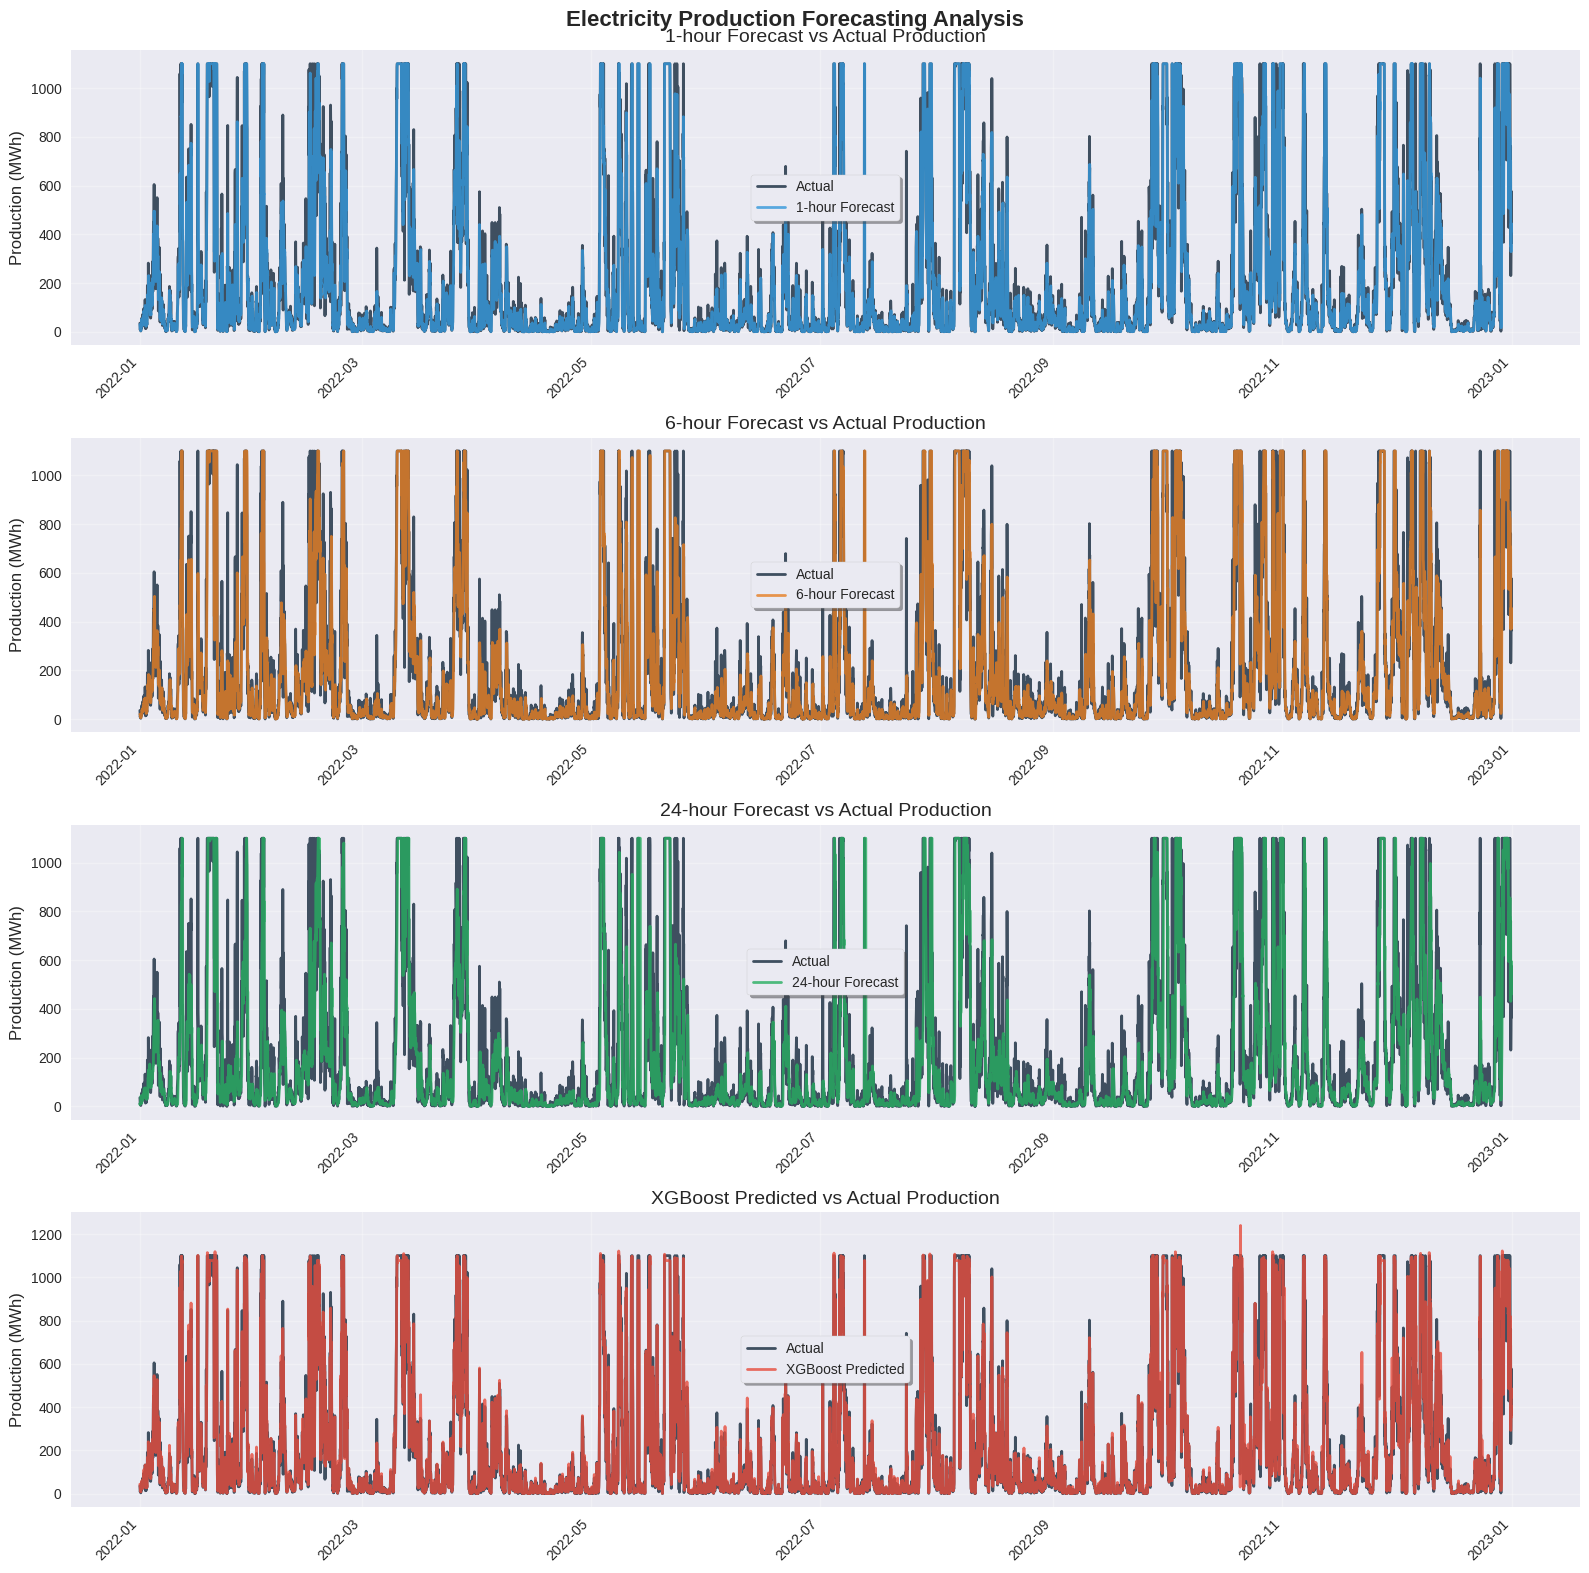


                   FORECASTING PERFORMANCE METRICS                    
Metric          1-hour       6-hour       24-hour      XGBoost     
----------------------------------------------------------------------
MAE (MWh)       32.89        46.56        67.90        43.29       
RMSE (MWh)      74.44        101.99       150.13       80.34       
MAPE (%)        710.88       2327.24      2480.40      64.94       
R²              0.9462       0.8989       0.7810       0.9505      
Bias (MWh)      -12.73       -18.73       -27.95       -0.00       


In [ ]:
"""
Plot forecasts
"""
def calculate_metrics(actual, forecast):
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast)**2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    r2 = 1 - np.sum((actual - forecast)**2) / np.sum((actual - np.mean(actual))**2)
    bias = np.mean(forecast - actual)
    return mae, rmse, mape, r2, bias

# Set plot style
plt.style.use('seaborn-v0_8')

# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Electricity Production Forecasting Analysis', fontsize=16, fontweight='bold')

# Define forecast data and colors
forecasts = [
    (forecasted_production_1, '1-hour Forecast', '#3498DB'),
    (forecasted_production_6, '6-hour Forecast', '#E67E22'),
    (forecasted_production_24, '24-hour Forecast', '#27AE60'),
    (predicted_production, 'XGBoost Predicted', '#E74C3C')
]

# Plot each forecast in its own subplot
for i, (forecast, label, color) in enumerate(forecasts):
    axes[i].plot(hourly_timestamps, actual_production, label='Actual',
                 color='#2C3E50', linewidth=2, alpha=0.9)

    linestyle = '-'
    axes[i].plot(hourly_timestamps, forecast, label=label,
                 color=color, linewidth=2, alpha=0.8, linestyle=linestyle)

    axes[i].set_ylabel('Production (MWh)', fontsize=12)
    axes[i].set_title(f'{label} vs Actual Production', fontsize=14)
    axes[i].legend(frameon=True, fancybox=True, shadow=True)
    axes[i].grid(True, alpha=0.3)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.tight_layout()
plt.show()

# Metrics
print("\n" + "="*70)
print(f"{'FORECASTING PERFORMANCE METRICS':^70}")
print("="*70)
print(f"{'Metric':<15} {'1-hour':<12} {'6-hour':<12} {'24-hour':<12} {'XGBoost':<12}")
print("-" * 70)
print(f"{'MAE (MWh)':<15} {metrics_1h[0]:<12.2f} {metrics_6h[0]:<12.2f} {metrics_24h[0]:<12.2f} {mae_xgboost:<12.2f}")
print(f"{'RMSE (MWh)':<15} {metrics_1h[1]:<12.2f} {metrics_6h[1]:<12.2f} {metrics_24h[1]:<12.2f} {rmse_xgboost:<12.2f}")
print(f"{'MAPE (%)':<15} {metrics_1h[2]:<12.2f} {metrics_6h[2]:<12.2f} {metrics_24h[2]:<12.2f} {mape_xgboost:<12.2f}")
print(f"{'R²':<15} {metrics_1h[3]:<12.4f} {metrics_6h[3]:<12.4f} {metrics_24h[3]:<12.4f} {r2_xgboost:<12.4f}")
print(f"{'Bias (MWh)':<15} {metrics_1h[4]:<12.2f} {metrics_6h[4]:<12.2f} {metrics_24h[4]:<12.2f} {np.mean(predicted_production - actual_production):<12.2f}")
print("="*70)

Conclusion: XGBoost model seems more reliable than just only using the given forecasts in the data

In [ ]:
"""
Finalised strategy: Plan buy and sells at start of each day
"""
def plan_today(starting_hydrogen,
                   todays_hydrogen_demand_forecast,
                   target_hydrogen,
                   todays_predicted_productions,
                   prices):

    """
    Simulate a days electricity production and hydrogen demands using forecasts.
    Use forecasted values to determine when to buy and sell electricity on actual day.
    Return array of actions to complete on actual day
    """

    # Conversion rates (1KWh produces 40KG hydrogen, efficiency included in the rates)
    hydrogen_to_electricity_rate = 1/29.6
    electricity_to_hydrogen_rate = 29.6
    HYDROGEN_STORAGE_CAPACITY_KG = 86000

    hydrogen_available = starting_hydrogen
    daily_actions = [(None, None)] * 24
    hourly_hydrogen_demand = todays_hydrogen_demand_forecast / 24
    hydrogen_production_forecast = todays_predicted_productions * electricity_to_hydrogen_rate
    cheapest_idx = np.argmin(prices)
    # mean_price = np.mean(prices)
    # std_price = np.std(prices)


    for j in range(24):
        # Buy electicity if not enough hydrogen from wind farm
        if hydrogen_available + hydrogen_production_forecast[j] < hourly_hydrogen_demand:
            shortage = hourly_hydrogen_demand - (hydrogen_available + hydrogen_production_forecast[j])
            daily_actions[j] = ("B", shortage * 1.8 * hydrogen_to_electricity_rate)
            hydrogen_available += shortage * 1.8
        # Sell hydrogen if theres enough hydrogen
        elif hydrogen_available > target_hydrogen and prices[j] > mean_price + std_price:
            excess = hydrogen_available - target_hydrogen
            daily_actions[j] = ("S", excess * hydrogen_to_electricity_rate)
            hydrogen_available -= excess
        # Buy electricity for hydrogen if price is low
        elif prices[j] < mean_price - std_price:
            available_capacity = HYDROGEN_STORAGE_CAPACITY_KG - hydrogen_available - hydrogen_production_forecast[j]

            if available_capacity > 0:
                hydrogen_to_buy = available_capacity * (prices[j] / mean_price)
                daily_actions[j] = ("B", hydrogen_to_buy * hydrogen_to_electricity_rate)
                hydrogen_available += hydrogen_to_buy
            else:
              daily_actions[j] = (None, None)
        else:
            daily_actions[j] = (None, None)

        hydrogen_available -= hourly_hydrogen_demand

        # Make sure tomorrows demand is met, ideally when price is cheapest
        if (j == 23 or j == cheapest_idx) and hydrogen_available < target_hydrogen:
            shortage = target_hydrogen - hydrogen_available
            daily_actions[j] = ("B", shortage * hydrogen_to_electricity_rate)
            hydrogen_available += shortage


    return daily_actions

# Get data
prices = current_prices.values
hydrogen_demand = actual_hydrogen_demand.values
hydrogen_demand_forecast = forecasted_hydrogen_demand.values
electricity_production = forecasted_production_1.values  # MWh
day_ahead_prices = day_ahead_prices_data.values

# Conversion rates (1 MWh -> 40kg * 0.74 = 29.6kg)
hydrogen_to_electricity_rate = 1/29.6
electricity_to_hydrogen_rate = 29.6

current_day = 0
hydrogen_available = 10000
cash = 10_000_000
demand_not_met_count = 0
todays_demand = 0

# Trackers
hydrogen_history = [hydrogen_available]
cash_history = [cash]
daily_cash = [cash]
demand_not_met_history = np.full(len(prices), 0)
electricity_sold_history = np.full(len(prices), 0)
electricty_bought_history = np.full(len(prices), 0)

# Predict production values
features = ["Production_Forecast_1hour_MWh", "Production_Forecast_6hour_MWh", "Production_Forecast_24hour_MWh"]
X = hourly_data[features]
predicted_productions = model.predict(X)


for i in range(len(prices)):
    if i % 24 == 0:
        if current_day >= len(hydrogen_demand) - 1:
            break

        # Set demands
        todays_hydrogen_demand = hydrogen_demand[current_day]
        todays_hydrogen_demand_forecast = hydrogen_demand_forecast[current_day]
        tomorrows_hydrogen_demand_forecast = hydrogen_demand_forecast[current_day + 1]
        hydrogen_used_per_hour = todays_hydrogen_demand / 24
        target_hydrogen = tomorrows_hydrogen_demand_forecast * 1.05  # Multiplier based on hydrogen demand forecast MAPE (2%)

        # Update trackers
        daily_cash.append(cash)

        # Get todays predicted hourly production from xgboost model
        todays_predicted_productions = predicted_productions[i:i+24]
        todays_day_ahead_prices = day_ahead_prices[i:i+24]

        # Simulate today to get actions for actual day
        daily_actions = plan_today(starting_hydrogen=hydrogen_available,
                                       todays_hydrogen_demand_forecast=todays_hydrogen_demand_forecast,
                                       target_hydrogen=target_hydrogen,
                                       todays_predicted_productions=todays_predicted_productions,
                                       prices=todays_day_ahead_prices)

        # Update date
        current_day += 1

    # Get current hour's action
    action, action_quantity = daily_actions[i%24]

    # This hours production
    hydrogen_production = electricity_production[i] * electricity_to_hydrogen_rate


    # Perform trades
    if action == "B":
        # Buy electricity
        if hydrogen_available + action_quantity <= HYDROGEN_STORAGE_CAPACITY_KG:
          cost = action_quantity * prices[i] * 1.1
          if cash >= cost:
              cash -= cost
              hydrogen_available += action_quantity * electricity_to_hydrogen_rate
              cash_history.append(cash)
          electricty_bought_history[i] = action_quantity

        # Update hydrogen availability using wind farm, can only update if electrolyser is in correct mode
        if hydrogen_available + hydrogen_production <= HYDROGEN_STORAGE_CAPACITY_KG:
            hydrogen_available += hydrogen_production
            hydrogen_production = 0
        else:
            hydrogen_production = (hydrogen_available + hydrogen_production) - HYDROGEN_STORAGE_CAPACITY_KG
            hydrogen_available = HYDROGEN_STORAGE_CAPACITY_KG


    elif action == "S":
        # Sell electricity
        cash += action_quantity * prices[i]
        cash_history.append(cash)
        hydrogen_available -= action_quantity * hydrogen_to_electricity_rate
        electricity_sold_history[i] = action_quantity

    # Sell left over wind farm electricity
    electricity_to_sell = hydrogen_production * hydrogen_to_electricity_rate
    if electricity_to_sell > 0:
        cash += electricity_to_sell * prices[i]
        cash_history.append(cash)

    # Update tracker
    if hydrogen_available < hydrogen_used_per_hour:
        demand_not_met_count += 1
        demand_not_met_history[i] = 1

    # Reduce hydrogen available due to usage in refinery
    hydrogen_available -= hydrogen_used_per_hour

    # Update tracker
    hydrogen_history.append(hydrogen_available)

print(f"Profit: {cash_history[-1] - cash_history[0]:.2f}")
print(f"Demand not met count: {demand_not_met_count}")
print(f"Final hydrogen available: {hydrogen_available:.2f} kg")

# cnt = 0
# for k in range(len(demand_not_met_history)):
#     if k % 24 == 0:
#         print(f"Day ({k//24}): {cnt}")
#         cnt = 0
#     else:
#         cnt += demand_not_met_history[k]


Profit: 186222187.16
Demand not met count: 0
Final hydrogen available: 69213.41 kg


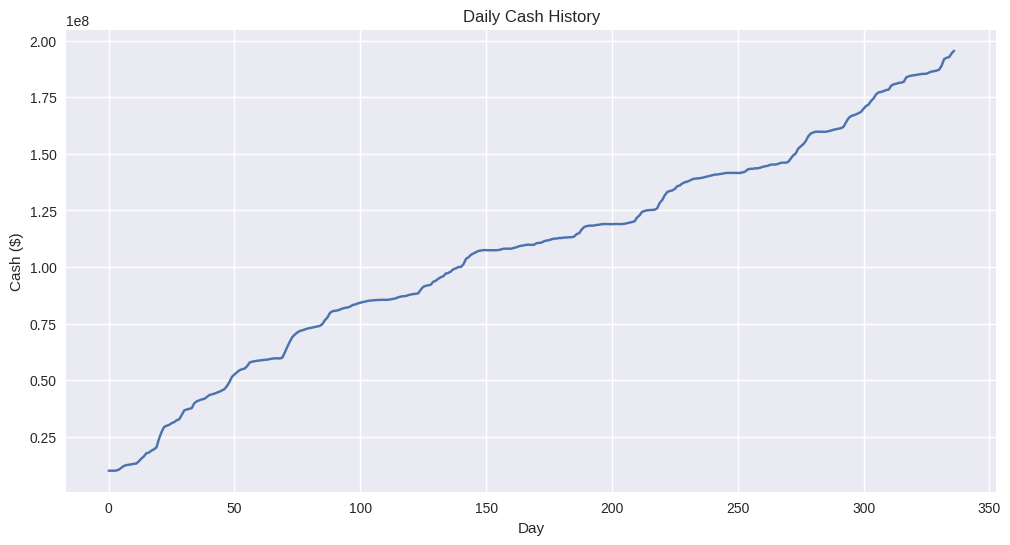

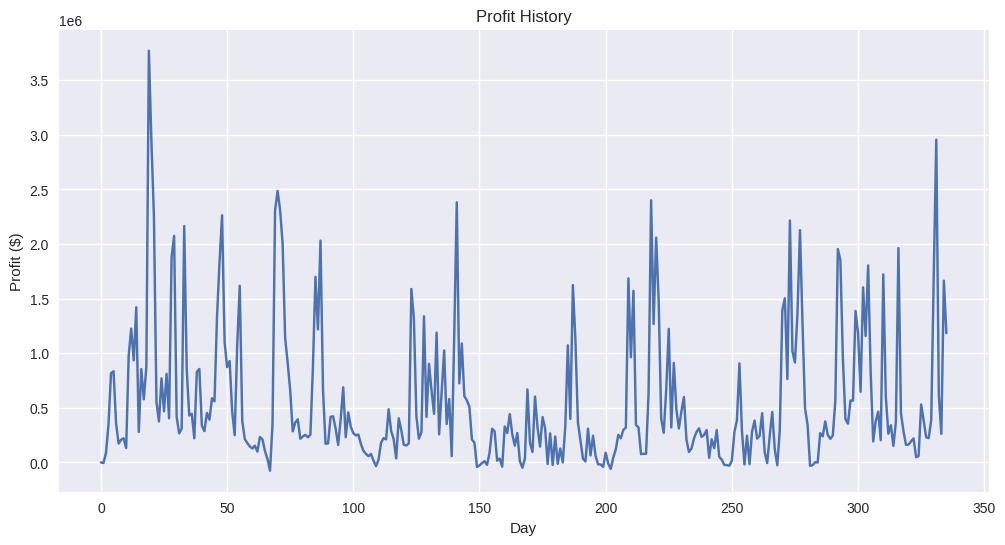

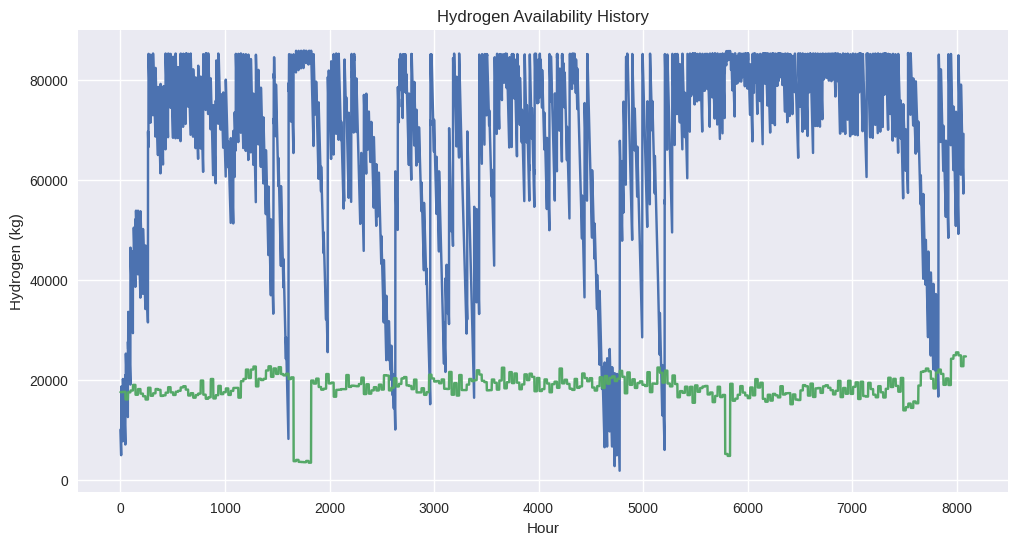

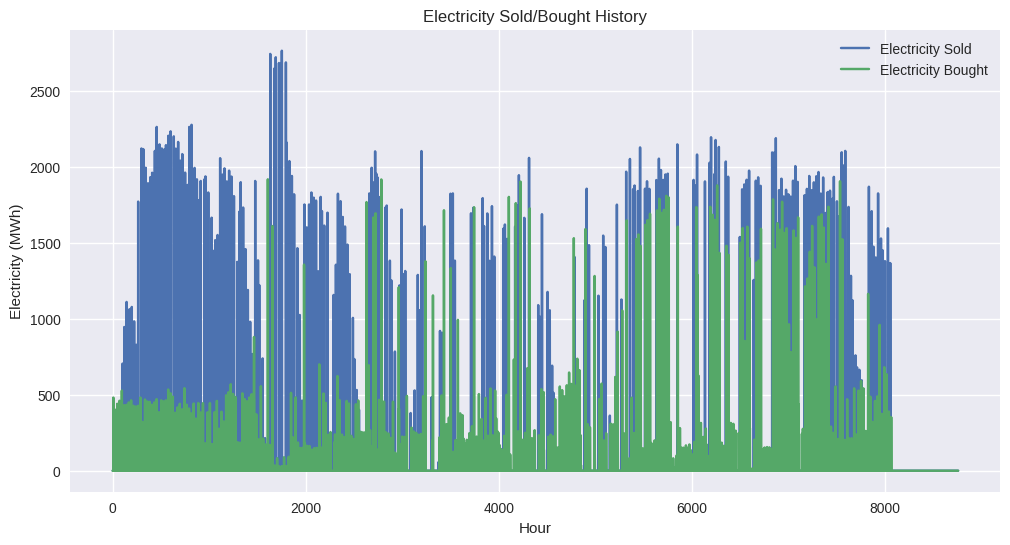

In [ ]:
"""
Plot cash history performamnce
"""
# Plot cash history
plt.figure(figsize=(12, 6))
plt.plot(daily_cash)
plt.xlabel('Day')
plt.ylabel('Cash ($)')
plt.title('Daily Cash History')

# Plot daily profit history
profit = [daily_cash[i] - daily_cash[i-1] for i in range(1, len(daily_cash))]
plt.figure(figsize=(12, 6))
plt.plot(profit)
plt.xlabel('Day')
plt.ylabel('Profit ($)')
plt.title('Profit History')
plt.show()

# Plot hydrogen availability history
hydrogen_demand_hourly = np.repeat(hydrogen_demand, 24)
plt.figure(figsize=(12, 6))
plt.plot(hydrogen_history)
plt.plot(hydrogen_demand_hourly)
plt.xlabel('Hour')
plt.ylabel('Hydrogen (kg)')
plt.title('Hydrogen Availability History')
plt.show()

# Plot electricity sold/bought
plt.figure(figsize=(12, 6))
plt.plot(electricity_sold_history, label='Electricity Sold')
plt.plot(electricty_bought_history, label='Electricity Bought')
plt.legend()
plt.xlabel('Hour')
plt.ylabel('Electricity (MWh)')
plt.title('Electricity Sold/Bought History')
plt.show()